In [171]:
import pandas as pd
import numpy as np


df = pd.read_csv("PRICED DATA.csv", sep=' ', )
print(df.shape)

(500, 51)


<Axes: >

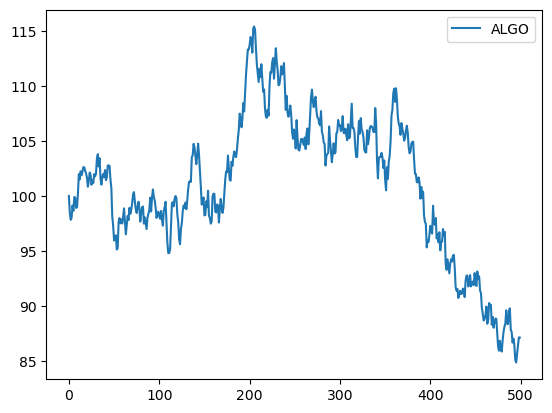

In [172]:
import matplotlib.pylab as plt



df1 = df.iloc[:, :1]

df1.plot()


<Axes: >

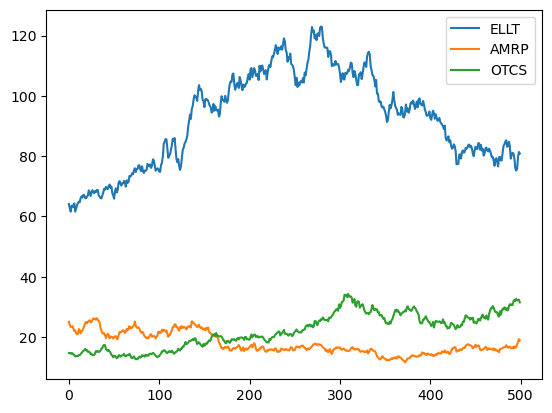

In [173]:
df2 = df.iloc[:, 4:7]

df2.plot()

# Momentum Strategy (per Andy's spec)

- Risk-adjusted momentum (return / realised vol), not raw returns.
- Blend of several lookback horizons, all shorter than the ~100-150 day cycle length visible in the volatile cluster.
- ADX trend-strength filter so we don't trade the noise on non-trending instruments.
- Two variants: per-instrument (time-series) momentum, which keeps each instrument's beta, and cross-sectional momentum (long top performers / short bottom performers), which is market-neutral by construction.

Data is 500 days x 51 instruments, close prices only (no OHLC), loaded above.

In [174]:
# ---- Strategy configuration ----
HORIZONS = [20, 40, 60]          # lookback windows (trading days) - all shorter than the ~100-150d cycle length
HORIZON_WEIGHTS = None            # None => equal weight across horizons; otherwise dict {horizon: weight}

ADX_PERIOD = 14                   # smoothing period for the ADX trend-strength filter
ADX_THRESHOLD = 20                # classic ADX cutoff: below ~20 = no clear trend, so we sit out

CS_QUANTILE = 0.2                 # cross-sectional strategy: long top 20%, short bottom 20% by blended signal

ANNUALIZATION = 252               # assumed trading days/year for Sharpe etc.

## Returns & the cycle-length check

Quick sanity check on the "100-150 day cycle" observation before picking horizons: plot rolling realised vol of the most volatile instruments.

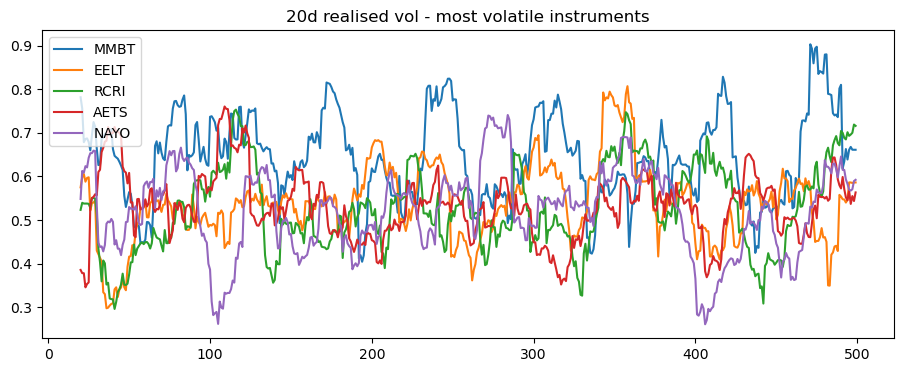

In [175]:
returns = df.pct_change()

# quick check on Andy's "100-150 day cycle" observation: look at rolling realised vol
# of the most volatile instruments to make sure our horizons sit comfortably inside it
vol_rank = returns.std().sort_values(ascending=False)
volatile_instruments = vol_rank.index[:5]

rolling_vol = returns[volatile_instruments].rolling(20).std() * np.sqrt(252)
rolling_vol.plot(figsize=(11, 4), title="20d realised vol - most volatile instruments")
plt.show()

## Risk-adjusted momentum, blended across horizons

For each horizon `h`, the signal is cumulative return over the last `h` days divided by realised vol over the same window - i.e. a rolling Sharpe ratio, not a raw return. This keeps signals comparable across instruments with very different vol, and across horizons, so blending (and later cross-sectional ranking) is on a like-for-like basis.

In [176]:
def risk_adjusted_momentum(rets, horizon):
    """Cumulative return over `horizon` days, normalised by realised vol over the same window."""
    cum_return = rets.rolling(horizon).sum()
    realised_vol = rets.rolling(horizon).std() * np.sqrt(horizon)
    return cum_return / realised_vol


signals = {h: risk_adjusted_momentum(returns, h) for h in HORIZONS}

if HORIZON_WEIGHTS is None:
    blended_signal = sum(signals.values()) / len(signals)
else:
    total_w = sum(HORIZON_WEIGHTS.values())
    blended_signal = sum(signals[h] * w for h, w in HORIZON_WEIGHTS.items()) / total_w

blended_signal.tail()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
495,-0.809953,0.379007,-0.533413,-0.578273,-0.428147,0.534608,1.499554,-2.306765,-0.383744,-0.140427,...,-0.522071,0.433084,-1.111419,0.763953,-0.559728,-1.182980,-0.280656,-0.847732,-1.813646,-1.385159
496,-0.627971,0.682191,-0.611216,-0.441687,-0.579584,0.909630,1.309553,-1.931460,-0.487094,0.070671,...,-0.376716,0.260862,-0.819401,0.683555,-0.277941,-1.018643,0.240380,-0.662077,-1.620748,-1.194174
497,-0.485527,0.772807,-0.564159,-0.047276,-0.044747,0.945285,1.163779,-1.460315,-0.216857,0.055225,...,-0.177152,0.442363,-0.329182,0.703539,-0.301037,-0.696220,0.344062,-0.246747,-1.417090,-1.356978
498,-0.187810,0.797154,-0.319012,0.105874,0.138666,1.260747,1.287827,-1.174157,-0.178745,0.322771,...,0.134800,0.726922,0.191143,0.874006,-0.235600,-0.792759,0.540966,0.032693,-1.075430,-1.108947
499,-0.215249,0.678978,-0.534986,0.042077,0.121163,0.954157,0.960907,-1.167819,-0.552762,0.390886,...,0.257186,0.546039,0.557344,0.885808,-0.069713,-0.996675,0.615416,0.376269,-1.006281,-1.107109


## ADX trend-strength filter

Classic ADX needs High/Low/Close to build True Range and directional movement. This dataset only has one close price per instrument per day, so True Range is proxied by the absolute close-to-close move and +DM/-DM by the signed move - same idea as ADX ("is price moving persistently in one direction"), just noisier than the textbook version. Swap in real OHLC here if/when it becomes available. Threshold of 20 is the standard "no clear trend below this" cutoff.

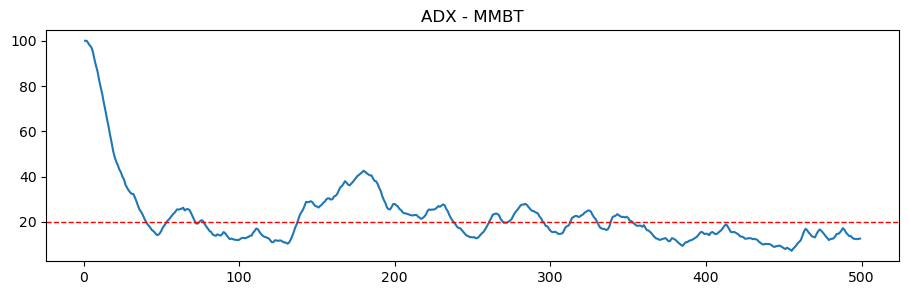

In [177]:
def compute_adx(prices, period=14):
    """Close-only ADX approximation (see markdown note above for why)."""
    move = prices.diff()
    plus_dm = move.clip(lower=0)
    minus_dm = (-move).clip(lower=0)
    tr = move.abs()

    atr = tr.ewm(alpha=1 / period, adjust=False).mean()
    plus_di = 100 * plus_dm.ewm(alpha=1 / period, adjust=False).mean() / atr.replace(0, np.nan)
    minus_di = 100 * minus_dm.ewm(alpha=1 / period, adjust=False).mean() / atr.replace(0, np.nan)

    di_sum = (plus_di + minus_di).replace(0, np.nan)
    dx = 100 * (plus_di - minus_di).abs() / di_sum
    adx = dx.ewm(alpha=1 / period, adjust=False).mean()
    return adx


adx = compute_adx(df, period=ADX_PERIOD)
trending = adx > ADX_THRESHOLD

adx[volatile_instruments[0]].plot(figsize=(11, 3), title=f"ADX - {volatile_instruments[0]}")
plt.axhline(ADX_THRESHOLD, color="red", linestyle="--", linewidth=1)
plt.show()

## Strategy 1: per-instrument (time-series) momentum

Directional position per instrument, sized by the blended signal (clipped for sanity) and switched off when ADX says the instrument isn't trending. Position is formed on day t's close and traded on day t+1's return (`shift(1)`) to avoid lookahead. This keeps each instrument's market beta - Andy's plan is to hedge that separately later.

In [178]:
raw_position = blended_signal.clip(-2, 2) / 2
ts_position = raw_position.where(trending, 0.0).shift(1)

ts_returns = (ts_position * returns).mean(axis=1)
ts_returns.tail()

495   -0.000824
496   -0.002871
497   -0.001477
498   -0.002732
499   -0.001071
dtype: float64

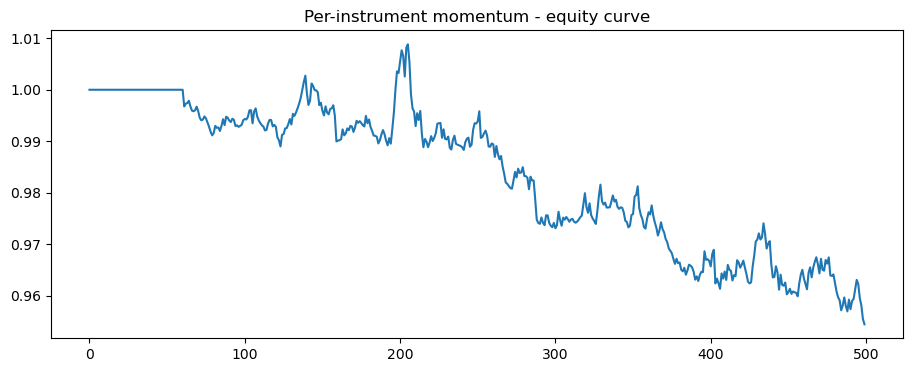

{'Ann. Return': np.float64(-0.024774657225157863),
 'Ann. Vol': np.float64(0.024858860666903806),
 'Sharpe': np.float64(-0.996612739301522),
 'Max Drawdown': np.float64(-0.053868018539992346)}

In [179]:
def perf_stats(strategy_returns, freq=ANNUALIZATION):
    r = strategy_returns.dropna()
    ann_return = r.mean() * freq
    ann_vol = r.std() * np.sqrt(freq)
    sharpe = ann_return / ann_vol
    equity = (1 + r).cumprod()
    max_dd = (equity / equity.cummax() - 1).min()
    return {
        "Ann. Return": ann_return,
        "Ann. Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
    }


ts_stats = perf_stats(ts_returns)
(1 + ts_returns.fillna(0)).cumprod().plot(figsize=(11, 4), title="Per-instrument momentum - equity curve")
plt.show()
ts_stats

## Strategy 2: cross-sectional momentum

Rank the blended signal across instruments each day, restricted to instruments that are actually trending (ADX filter). Go long the top `CS_QUANTILE`, short the bottom `CS_QUANTILE`, equal-weighted within each leg and dollar-neutral across legs (long 50% gross / short 50% gross) - this is the market-neutral version Andy mentioned, so it shouldn't need a separate beta hedge.

In [180]:
eligible_signal = blended_signal.where(trending)
pct_rank = eligible_signal.rank(axis=1, pct=True)

long_mask = pct_rank >= (1 - CS_QUANTILE)
short_mask = pct_rank <= CS_QUANTILE

n_long = long_mask.sum(axis=1).replace(0, np.nan)
n_short = short_mask.sum(axis=1).replace(0, np.nan)

cs_weights = (
    long_mask.div(n_long, axis=0) * 0.5
    - short_mask.div(n_short, axis=0) * 0.5
).fillna(0.0).shift(1)

cs_returns = (cs_weights * returns).sum(axis=1)
cs_returns.tail()

495   -0.006996
496   -0.010688
497   -0.008449
498   -0.004887
499   -0.004309
dtype: float64

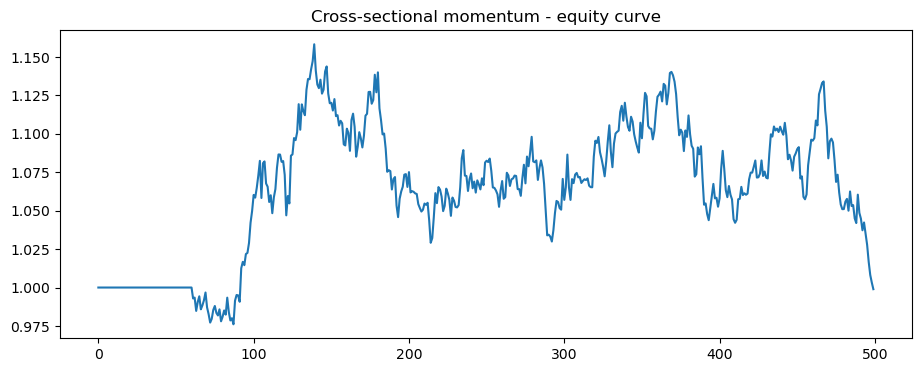

{'Ann. Return': np.float64(0.007529439833347284),
 'Ann. Vol': np.float64(0.12720838354091735),
 'Sharpe': np.float64(0.05918980827962014),
 'Max Drawdown': np.float64(-0.13756479762853935)}

In [181]:
cs_stats = perf_stats(cs_returns)
(1 + cs_returns.fillna(0)).cumprod().plot(figsize=(11, 4), title="Cross-sectional momentum - equity curve")
plt.show()
cs_stats

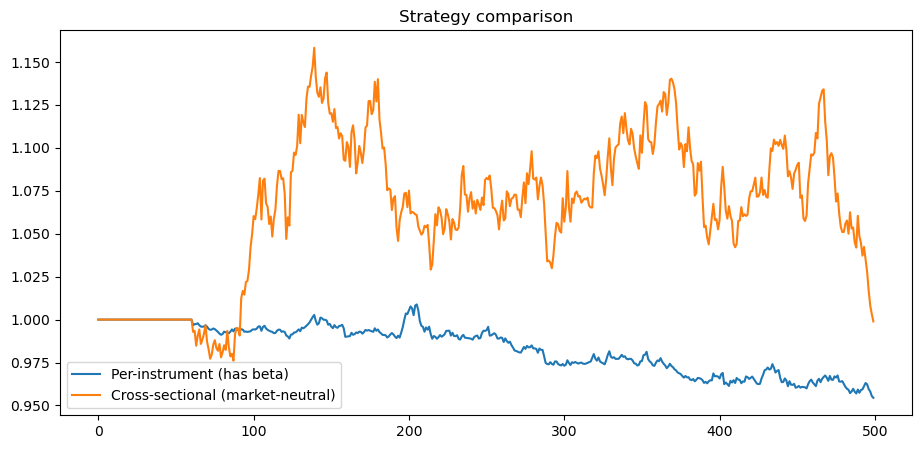

,Per-instrument,Cross-sectional
Ann. Return,-0.024775,0.007529
Ann. Vol,0.024859,0.127208
Sharpe,-0.996613,0.059190
Max Drawdown,-0.053868,-0.137565


In [182]:
comparison = pd.DataFrame({
    "Per-instrument (has beta)": (1 + ts_returns.fillna(0)).cumprod(),
    "Cross-sectional (market-neutral)": (1 + cs_returns.fillna(0)).cumprod(),
})
comparison.plot(figsize=(11, 5), title="Strategy comparison")
plt.show()

pd.DataFrame({"Per-instrument": ts_stats, "Cross-sectional": cs_stats})

### Notes for Andy

- **Risk-adjusted momentum**: cumulative return over each lookback divided by realised vol over the same window (a rolling Sharpe ratio) - that's what's blended across horizons, not raw returns.
- **Horizons**: 20/40/60 trading days, all inside the ~100-150 day cycle length spotted in the volatile cluster (see the diagnostic plot above). Change via `HORIZONS` / `HORIZON_WEIGHTS` at the top.
- **ADX**: this dataset only has close prices (no High/Low), so True Range and +DM/-DM are proxied from close-to-close moves. It behaves like ADX but is noisier - worth swapping in real OHLC if/when it's available. Threshold of 20 is the standard "no trend" cutoff, tunable via `ADX_THRESHOLD`.
- **Per-instrument strategy** keeps each instrument's market beta, as flagged - a beta hedge can be layered on top later.
- **Cross-sectional strategy** is long/short equal dollar amounts across the top/bottom `CS_QUANTILE` of trending instruments, so it's market-neutral by construction.
- All positions are lagged one day (`shift(1)`) before being applied to returns to avoid lookahead bias.
- All key parameters live in the config cell near the top for easy iteration.

---

# Validated pipeline

Everything above was built on the full 500 days and is useful for intuition, but it's an in-sample backtest - it will look better than it should. Below re-does this properly to match the team's shared protocol:

- **400/100 split**: build everything on the first 400 days; the last 100 days are touched exactly once, at the very end, as a holdout estimate.
- **Walk-forward validation**: train window 250 days, test window 60 days, refit parameters on train and apply them unmodified on test.
- **Conviction output**: a calibrated expected-return signal (not just a z-score), so this can be combined with Reji's and Cooky's strategies later.
- **ALGO beta-neutralization**: ALGO turns out to be ~0.99 correlated with an equal-weight basket of the other 50 instruments - it's effectively the market index. The cross-sectional strategy is rebuilt on ALGO-residual returns (and drops ALGO from the ranking universe) so it's ranking genuine relative strength, not just beta-to-ALGO. The per-instrument book is left on raw returns on purpose - it's supposed to carry beta, and that's what the portfolio-level ALGO hedge overlay is for.

In [183]:
# Evidence for the ALGO / market-index observation
algo_corr_basket = returns["ALGO"].corr(returns.drop(columns=["ALGO"]).mean(axis=1))
print(f"corr(ALGO, equal-weight basket of other 50) = {algo_corr_basket:.3f}")

returns.drop(columns=["ALGO"]).corrwith(returns["ALGO"]).sort_values(ascending=False).head(10)

corr(ALGO, equal-weight basket of other 50) = 0.993


ILVX    0.590823
BENI    0.525946
CUBO    0.522732
DUCT    0.522115
BLBT    0.521960
GARI    0.520269
SRNA    0.512269
FWWG    0.500572
ACIX    0.492797
ITPA    0.489877
dtype: float64

## Reusable building blocks

Same math as the exploratory section above, wrapped as functions so it can be re-run on any price slice (train windows, test windows, the holdout) without copy-pasting. `risk_adjusted_momentum`, `compute_adx`, and `perf_stats` from above are reused as-is.

In [184]:
def compute_blended_signal(rets, horizons, weights=None):
    sigs = {h: risk_adjusted_momentum(rets, h) for h in horizons}
    if weights is None:
        return sum(sigs.values()) / len(sigs)
    total_w = sum(weights.values())
    return sum(sigs[h] * w for h, w in weights.items()) / total_w


def neutralize_vs_algo(rets, algo_col="ALGO", window=60):
    """Rolling-beta residual returns vs ALGO (our market-index proxy). Reusable later
    by the hedge overlay too, since it's the same rolling-beta calculation."""
    algo_rets = rets[algo_col]
    cov = rets.rolling(window).cov(algo_rets)
    var = algo_rets.rolling(window).var()
    beta = cov.div(var, axis=0)
    return rets.sub(beta.mul(algo_rets, axis=0))

## Position-level risk limits

The cross-sectional book's equal-weight-within-leg construction (0.5/n_long, 0.5/n_short) is fine when breadth is healthy, but on days when the ADX+Hurst filter leaves only 1-2 eligible names in a leg, it concentrates half the book's capital into a single name - a real single-name risk that the return/Sharpe view doesn't surface. Two hard limits, applied to every book:

- **`MIN_NAMES_PER_LEG`**: if a leg has fewer eligible names than this, that leg sits out entirely that day (zero positions) rather than concentrating into whoever's left. Applied independently to the long and short legs.
- **`MAX_POSITION_PCT`**: hard cap on any single instrument's position, as a fraction of capital. Enforced by clipping - **not** redistributed to other names, so a thin day can leave the book under-invested (lower gross exposure) rather than forcing risk into fewer positions. That's a deliberate capital-preservation choice, not an oversight; happy to revisit if the desk would rather redistribute and stay fully invested.

Both are checked automatically wherever positions are computed (grid search, walk-forward OOS, and the holdout), so this isn't just applied at the reporting stage - the backtest itself only ever sees positions the risk desk would actually let through.

In [185]:
MIN_NAMES_PER_LEG = 3   # a leg with fewer eligible names than this sits out entirely that day
MAX_POSITION_PCT = 0.05  # hard cap: no single instrument can exceed 5% of capital, long or short


def apply_position_cap(weights, max_pct=MAX_POSITION_PCT):
    """Clip - never redistribute. See markdown above for why."""
    return weights.clip(lower=-max_pct, upper=max_pct)

In [186]:
def ts_weights_from_signal(blended, is_trending, n_instruments):
    """Per-instrument weight, as a fraction of total capital - keeps beta by design."""
    position = (blended.clip(-2, 2) / 2).where(is_trending, 0.0).shift(1)
    return apply_position_cap(position / n_instruments)


def ts_returns_from_signal(blended, is_trending, rets):
    weights = ts_weights_from_signal(blended, is_trending, rets.shape[1])
    return (weights * rets).sum(axis=1)


def cs_weights_from_signal(blended, is_trending, quantile, exclude_col=None, min_names_per_leg=MIN_NAMES_PER_LEG):
    """Cross-sectional weights, as a fraction of total capital (sums to +0.5 long / -0.5 short
    when breadth allows - see MIN_NAMES_PER_LEG / MAX_POSITION_PCT above)."""
    eligible = blended.where(is_trending)
    if exclude_col is not None:
        eligible = eligible.drop(columns=[exclude_col])
    pct_rank = eligible.rank(axis=1, pct=True)

    long_mask = pct_rank >= (1 - quantile)
    short_mask = pct_rank <= quantile

    n_long = long_mask.sum(axis=1)
    n_short = short_mask.sum(axis=1)
    long_mask = long_mask.where(n_long.ge(min_names_per_leg), other=False, axis=0)
    short_mask = short_mask.where(n_short.ge(min_names_per_leg), other=False, axis=0)
    n_long = long_mask.sum(axis=1).replace(0, np.nan)
    n_short = short_mask.sum(axis=1).replace(0, np.nan)

    weights = (
        long_mask.div(n_long, axis=0) * 0.5
        - short_mask.div(n_short, axis=0) * 0.5
    ).fillna(0.0).shift(1)

    return apply_position_cap(weights)


def cs_returns_from_signal(blended, is_trending, rets, quantile, exclude_col=None):
    """Cross-sectional strategy. Pass the ALGO-residual blended signal in to trade
    idiosyncratic relative strength instead of beta-to-ALGO."""
    weights = cs_weights_from_signal(blended, is_trending, quantile, exclude_col)
    return (weights * rets[weights.columns]).sum(axis=1)


def sharpe(r, freq=ANNUALIZATION):
    r = r.dropna()
    if len(r) == 0 or r.std() == 0:
        return -np.inf
    return (r.mean() * freq) / (r.std() * np.sqrt(freq))

## Hurst exponent screen

The autocorrelation check earlier showed most instruments mean-revert, not trend, at the horizons momentum trades (negative past-vs-forward return correlation at every horizon from 10 to 100 days, strengthening with horizon). ADX measures trend *strength* but can't tell trending from mean-reverting - a sharp reversal looks "strong" to it too. The Hurst exponent can: `H < 0.5` = mean-reverting, `H = 0.5` = random walk, `H > 0.5` = trending/persistent.

We add this as a second, independent filter alongside ADX: per-instrument momentum only trades where **both** say trending. `HURST_THRESHOLD = 0.5` is the standard textbook cutoff and is deliberately left fixed rather than added to the grid search - the point of this filter is to stop trading instruments where the underlying process works against momentum, not to search for whatever cutoff happens to produce the best-looking backtest on this one sample.

Estimated on a trailing 100-day window, re-estimated every 10 days and forward-filled (a regime classification doesn't need re-fitting daily) - no lookahead, since each estimate only uses prices up to and including the day it's assigned to.

In [196]:
def hurst_exponent(x, lags = np.arange(2, window // 10 + 1)):
    """Rescaled-range-style Hurst estimate from a price series."""
    x = np.asarray(x, dtype=float)
    tau = np.array([np.std(x[lag:] - x[:-lag]) for lag in lags])
    valid = tau > 0
    if valid.sum() < 2:
        return np.nan
    poly = np.polyfit(np.log(np.array(list(lags))[valid]), np.log(tau[valid]), 1)
    return poly[0] 


HURST_WINDOW = 100
HURST_STEP = 10
HURST_THRESHOLD = 0.5


def rolling_hurst(prices, window=HURST_WINDOW, step=HURST_STEP):
    hurst = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)
    for pos in range(window, len(prices) + 1, step):
        row_label = prices.index[pos - 1]
        window_slice = prices.iloc[pos - window:pos]
        hurst.loc[row_label] = [hurst_exponent(window_slice[col].values) for col in prices.columns]
    return hurst.ffill()

NameError: name 'window' is not defined

## Data split

First 400 days = build set (everything below is developed and validated on this). Last 100 days = holdout - touched exactly once, at the very end, with parameters already frozen. No retuning against it.

In [188]:
BUILD, HOLDOUT = df.iloc[:400], df.iloc[400:]

ALGO_NEUTRALIZE_WINDOW = 60  # rolling window for beta-vs-ALGO used to build cross-sectional residual returns

returns_build = BUILD.pct_change()
adx_build = compute_adx(BUILD, period=ADX_PERIOD)
hurst_build = rolling_hurst(BUILD)
resid_returns_build = neutralize_vs_algo(returns_build, algo_col="ALGO", window=ALGO_NEUTRALIZE_WINDOW)

# sanity check: residual returns should be ~uncorrelated with ALGO's own returns
print("max |corr(residual, ALGO)| across instruments:",
      resid_returns_build.drop(columns=["ALGO"]).corrwith(returns_build["ALGO"]).abs().max())

# how much of the universe actually clears the Hurst bar?
print("fraction of instrument-days with Hurst > threshold:", (hurst_build > HURST_THRESHOLD).mean().mean())

max |corr(residual, ALGO)| across instruments: 0.04610927596886052
fraction of instrument-days with Hurst > threshold: 0.36627450980392157


## Walk-forward validation

Train window 250 days, test window 60 days, sliding forward by the test window each fold (over 400 build days that gives 2 full folds; the last 30 leftover days are too short for another test window and are dropped rather than forced into a partial fold).

On each train window we grid-search `HORIZONS`, `ADX_THRESHOLD`, and `CS_QUANTILE` (ts and cs optimized separately, since they don't need the same parameters) by train-window Sharpe, then apply the winning combo unmodified on the next test window. `ADX_PERIOD`, `HURST_THRESHOLD`, and the ALGO-neutralization window are left fixed - only the momentum-specific knobs are tuned. An instrument-day is only tradeable when **both** ADX and Hurst agree it's trending.

Signals are computed once per horizon-set over the *entire* build set (not recomputed cold within each slice) so rolling windows have proper history at the start of every test block - slicing happens after the rolling computation, not before.

In [189]:
PARAM_GRID = {
    "horizons": [(20, 40, 60), (15, 30, 45), (10, 20, 40)],
    "adx_threshold": [15, 20, 25],
    "cs_quantile": [0.1, 0.2, 0.3],
}

TRAIN_WINDOW = 250
TEST_WINDOW = 60

# precompute the (expensive) rolling signal for every horizon-set, once, over the full build range
signal_cache = {
    horizons: {
        "raw": compute_blended_signal(returns_build, horizons),
        "resid": compute_blended_signal(resid_returns_build, horizons),
    }
    for horizons in PARAM_GRID["horizons"]
}


def build_fold_ranges(n_days, train_window, test_window):
    folds, start = [], 0
    while start + train_window + test_window <= n_days:
        folds.append(((start, start + train_window), (start + train_window, start + train_window + test_window)))
        start += test_window
    return folds


fold_ranges = build_fold_ranges(len(BUILD), TRAIN_WINDOW, TEST_WINDOW)
fold_ranges

[((0, 250), (250, 310)), ((60, 310), (310, 370))]

In [190]:
def grid_search(row_range):
    r0, r1 = row_range
    rets = returns_build.iloc[r0:r1]
    trend = adx_build.iloc[r0:r1]
    hurst = hurst_build.iloc[r0:r1]

    best_ts, best_cs = None, None
    for horizons in PARAM_GRID["horizons"]:
        blended_raw = signal_cache[horizons]["raw"].iloc[r0:r1]
        blended_resid = signal_cache[horizons]["resid"].iloc[r0:r1]

        for adx_threshold in PARAM_GRID["adx_threshold"]:
            is_trending = (trend > adx_threshold) & (hurst > HURST_THRESHOLD)

            ts_ret = ts_returns_from_signal(blended_raw, is_trending, rets)
            s_ts = sharpe(ts_ret)
            if best_ts is None or s_ts > best_ts["sharpe"]:
                best_ts = {"sharpe": s_ts, "horizons": horizons, "adx_threshold": adx_threshold}

            for cs_quantile in PARAM_GRID["cs_quantile"]:
                cs_ret = cs_returns_from_signal(blended_resid, is_trending, rets, cs_quantile, exclude_col="ALGO")
                s_cs = sharpe(cs_ret)
                if best_cs is None or s_cs > best_cs["sharpe"]:
                    best_cs = {"sharpe": s_cs, "horizons": horizons, "adx_threshold": adx_threshold, "cs_quantile": cs_quantile}

    return best_ts, best_cs


ts_oos_parts, cs_oos_parts, fold_params = [], [], []
ts_weight_parts, cs_weight_parts = [], []  # kept for dollar sizing below

for train_range, test_range in fold_ranges:
    best_ts, best_cs = grid_search(train_range)
    fold_params.append({"train_range": train_range, "test_range": test_range, "ts": best_ts, "cs": best_cs})

    t0, t1 = test_range
    rets_test = returns_build.iloc[t0:t1]
    hurst_test = hurst_build.iloc[t0:t1]

    is_trending_ts = (adx_build.iloc[t0:t1] > best_ts["adx_threshold"]) & (hurst_test > HURST_THRESHOLD)
    blended_raw_test = signal_cache[best_ts["horizons"]]["raw"].iloc[t0:t1]
    ts_weight_parts.append(ts_weights_from_signal(blended_raw_test, is_trending_ts, rets_test.shape[1]))
    ts_oos_parts.append(ts_returns_from_signal(blended_raw_test, is_trending_ts, rets_test))

    is_trending_cs = (adx_build.iloc[t0:t1] > best_cs["adx_threshold"]) & (hurst_test > HURST_THRESHOLD)
    blended_resid_test = signal_cache[best_cs["horizons"]]["resid"].iloc[t0:t1]
    cs_weight_parts.append(cs_weights_from_signal(blended_resid_test, is_trending_cs, best_cs["cs_quantile"], exclude_col="ALGO"))
    cs_oos_parts.append(cs_returns_from_signal(
        blended_resid_test, is_trending_cs, rets_test, best_cs["cs_quantile"], exclude_col="ALGO"
    ))

ts_oos = pd.concat(ts_oos_parts)
cs_oos = pd.concat(cs_oos_parts)
ts_weight_oos = pd.concat(ts_weight_parts)
cs_weight_oos = pd.concat(cs_weight_parts)

for fp in fold_params:
    print(fp)

{'train_range': (0, 250), 'test_range': (250, 310), 'ts': {'sharpe': np.float64(0.8709399268770617), 'horizons': (10, 20, 40), 'adx_threshold': 20}, 'cs': {'sharpe': np.float64(0.4841880210416049), 'horizons': (15, 30, 45), 'adx_threshold': 15, 'cs_quantile': 0.3}}
{'train_range': (60, 310), 'test_range': (310, 370), 'ts': {'sharpe': np.float64(0.27507119873236513), 'horizons': (10, 20, 40), 'adx_threshold': 20}, 'cs': {'sharpe': np.float64(1.0832498528282057), 'horizons': (10, 20, 40), 'adx_threshold': 15, 'cs_quantile': 0.3}}


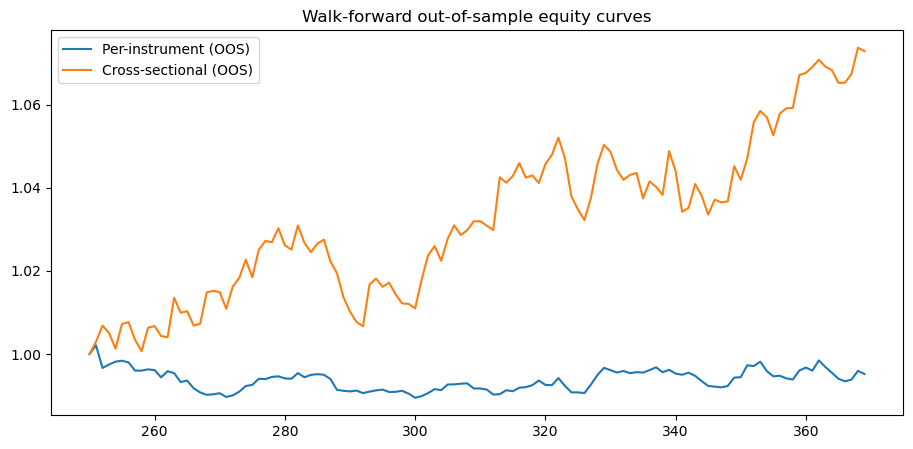

,Per-instrument (OOS),Cross-sectional (OOS)
Ann. Return,-0.009908,0.149770
Ann. Vol,0.018443,0.064568
Sharpe,-0.537225,2.319571
Max Drawdown,-0.012594,-0.023507


In [191]:
# out-of-sample performance - this is the number to trust, not the full-sample backtest above
oos_comparison = pd.DataFrame({
    "Per-instrument (OOS)": (1 + ts_oos.fillna(0)).cumprod(),
    "Cross-sectional (OOS)": (1 + cs_oos.fillna(0)).cumprod(),
})
oos_comparison.plot(figsize=(11, 5), title="Walk-forward out-of-sample equity curves")
plt.show()

pd.DataFrame({"Per-instrument (OOS)": perf_stats(ts_oos), "Cross-sectional (OOS)": perf_stats(cs_oos)})

## Conviction: a calibrated expected-return output

The signal above is a risk-adjusted z-score-like number, useful for ranking but not directly comparable to what Reji/Cooky will produce. To turn it into something combinable, fit `edge = slope * signal`, where `slope = cov(signal, forward_return) / var(signal)` is estimated on each train window (pooled across instruments and days) and applied unmodified on the following test window - same walk-forward discipline as the parameters above, so this is also out-of-sample. Output is in daily-return units.

`ts_conviction` and `cs_conviction` are kept separate (they're different books), plus a combined `momentum_conviction` for convenience.

In [192]:
def calibrate_slope(signal_df, forward_return_df):
    x, y = signal_df.values.ravel(), forward_return_df.values.ravel()
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) == 0 or np.var(x) == 0:
        return 0.0
    return np.cov(x, y, bias=True)[0, 1] / np.var(x)


fwd_returns_build = returns_build.shift(-1)  # day t signal trades day t+1's return

ts_conviction_parts, cs_conviction_parts = [], []

for fp in fold_params:
    t0, t1 = fp["train_range"]
    s0, s1 = fp["test_range"]
    hurst_test = hurst_build.iloc[s0:s1]

    ts_h = fp["ts"]["horizons"]
    ts_slope = calibrate_slope(signal_cache[ts_h]["raw"].iloc[t0:t1], fwd_returns_build.iloc[t0:t1])
    ts_trending_test = (adx_build.iloc[s0:s1] > fp["ts"]["adx_threshold"]) & (hurst_test > HURST_THRESHOLD)
    ts_conviction_parts.append((signal_cache[ts_h]["raw"].iloc[s0:s1] * ts_slope).where(ts_trending_test, 0.0))

    cs_h = fp["cs"]["horizons"]
    cs_slope = calibrate_slope(signal_cache[cs_h]["resid"].iloc[t0:t1], fwd_returns_build.iloc[t0:t1])
    cs_trending_test = (adx_build.iloc[s0:s1] > fp["cs"]["adx_threshold"]) & (hurst_test > HURST_THRESHOLD)
    cs_conviction_parts.append((signal_cache[cs_h]["resid"].iloc[s0:s1] * cs_slope).where(cs_trending_test, 0.0))

    print(f"fold test {fp['test_range']}: ts_slope={ts_slope:.5f}, cs_slope={cs_slope:.5f}")

ts_conviction = pd.concat(ts_conviction_parts)
cs_conviction = pd.concat(cs_conviction_parts)
momentum_conviction = ts_conviction.add(cs_conviction, fill_value=0.0)

momentum_conviction.tail()

fold test (250, 310): ts_slope=-0.00043, cs_slope=0.00001
fold test (310, 370): ts_slope=-0.00056, cs_slope=0.00001


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
365,0.0,-0.000007,0.00000,-0.000752,0.0,0.0,-0.000262,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,-0.000010,-0.001305,3.325138e-06,-0.000362,0.0,0.0
366,0.0,-0.000009,0.00000,-0.000847,0.0,0.0,-0.000299,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,-0.000011,-0.001228,2.157810e-08,-0.000373,0.0,0.0
367,0.0,-0.000005,0.00000,-0.000808,0.0,0.0,0.000002,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,-0.000011,-0.001137,-4.758798e-07,-0.000128,0.0,0.0
368,0.0,-0.000004,0.00000,-0.000954,0.0,0.0,0.000004,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,-0.000013,-0.001316,0.000000e+00,-0.000425,0.0,0.0
369,0.0,-0.000004,-0.00083,-0.000707,0.0,0.0,0.000004,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00001,-0.000012,-0.001121,0.000000e+00,-0.000414,0.0,0.0


## Holdout evaluation (one shot)

Freeze the last fold's winning parameters and run once, unmodified, on the 100-day holdout. Signals are computed on the full 500-day price history so the holdout's rolling windows have real warmup (no lookahead - day t's signal only ever uses data up to day t-1), then we only look at performance from day 400 onward. This number is an estimate, not a target - don't come back and retune against it.

In [193]:
final_params = fold_params[-1]
print("Frozen params for holdout:", final_params["ts"], final_params["cs"])

returns_full = df.pct_change()
adx_full = compute_adx(df, period=ADX_PERIOD)
hurst_full = rolling_hurst(df)
resid_returns_full = neutralize_vs_algo(returns_full, algo_col="ALGO", window=ALGO_NEUTRALIZE_WINDOW)

blended_raw_full = compute_blended_signal(returns_full, final_params["ts"]["horizons"])
blended_resid_full = compute_blended_signal(resid_returns_full, final_params["cs"]["horizons"])

is_trending_ts_holdout = (adx_full.iloc[400:] > final_params["ts"]["adx_threshold"]) & (hurst_full.iloc[400:] > HURST_THRESHOLD)
is_trending_cs_holdout = (adx_full.iloc[400:] > final_params["cs"]["adx_threshold"]) & (hurst_full.iloc[400:] > HURST_THRESHOLD)

ts_weight_holdout = ts_weights_from_signal(blended_raw_full.iloc[400:], is_trending_ts_holdout, returns_full.shape[1])
ts_holdout = ts_returns_from_signal(blended_raw_full.iloc[400:], is_trending_ts_holdout, returns_full.iloc[400:])

cs_weight_holdout = cs_weights_from_signal(
    blended_resid_full.iloc[400:], is_trending_cs_holdout, final_params["cs"]["cs_quantile"], exclude_col="ALGO"
)
cs_holdout = cs_returns_from_signal(
    blended_resid_full.iloc[400:], is_trending_cs_holdout, returns_full.iloc[400:],
    final_params["cs"]["cs_quantile"], exclude_col="ALGO"
)

pd.DataFrame({"Per-instrument (holdout)": perf_stats(ts_holdout), "Cross-sectional (holdout)": perf_stats(cs_holdout)})

Frozen params for holdout: {'sharpe': np.float64(0.27507119873236513), 'horizons': (10, 20, 40), 'adx_threshold': 20} {'sharpe': np.float64(1.0832498528282057), 'horizons': (10, 20, 40), 'adx_threshold': 15, 'cs_quantile': 0.3}


,Per-instrument (holdout),Cross-sectional (holdout)
Ann. Return,-0.026080,-0.063517
Ann. Vol,0.015176,0.045288
Sharpe,-1.718469,-1.402501
Max Drawdown,-0.013001,-0.039892


## Stop-loss overlay

A per-position stop: track the cumulative P&L of each instrument's position since it was last flat or changed direction, and force it flat for `STOP_LOSS_COOLDOWN` days once that P&L breaches `-STOP_LOSS_PCT`. This is deliberately implemented as a sequential, day-by-day loop rather than a vectorized rolling calculation, so the lookahead logic is unambiguous to audit: a stop decided using day t's return can only force day t+1's position flat, never day t's own - day t's position was already committed (formed from day t-1's signal) before day t's return was known, so it can't be un-traded after the fact.

Like the position limits above, `STOP_LOSS_PCT`/`STOP_LOSS_COOLDOWN` are fixed, round numbers, not grid-searched - the point is a sane backstop against a signal error or regime break, not another lever to tune for a better-looking backtest. Applied as an overlay on top of the already-selected walk-forward parameters, with a before/after comparison so the effect is visible rather than assumed.

In [194]:
STOP_LOSS_PCT = 0.08       # flatten a position once its P&L since entry breaches this
STOP_LOSS_COOLDOWN = 10    # trading days to stay flat after a stop-out before re-entry is allowed


def apply_stop_loss(weights, rets, stop_loss_pct=STOP_LOSS_PCT, cooldown=STOP_LOSS_COOLDOWN):
    cols = weights.columns
    out = weights.copy()
    pnl_since_entry = pd.Series(0.0, index=cols)
    prev_sign = pd.Series(0.0, index=cols)
    cooldown_remaining = pd.Series(0, index=cols)

    for day in weights.index:
        active_cooldown = cooldown_remaining > 0
        out.loc[day] = out.loc[day].where(~active_cooldown, 0.0)
        w_today = out.loc[day]
        curr_sign = np.sign(w_today)

        r_today = rets.loc[day].reindex(cols).fillna(0.0) if day in rets.index else pd.Series(0.0, index=cols)

        fresh = curr_sign != prev_sign
        baseline = pnl_since_entry.where(~fresh, 0.0)
        pnl_since_entry = (1 + baseline) * (1 + curr_sign * r_today) - 1
        pnl_since_entry = pnl_since_entry.where(curr_sign != 0, 0.0)

        newly_stopped = pnl_since_entry <= -stop_loss_pct
        cooldown_remaining = pd.Series(
            np.where(newly_stopped, cooldown, np.maximum(cooldown_remaining.values - 1, 0)),
            index=cols,
        )
        pnl_since_entry = pnl_since_entry.where(~newly_stopped, 0.0)
        prev_sign = curr_sign

    return out


def count_flattened(before, after):
    return int(((before != 0) & (after == 0)).sum().sum())


ts_weight_oos_sl = apply_stop_loss(ts_weight_oos, returns_build.loc[ts_weight_oos.index])
cs_weight_oos_sl = apply_stop_loss(cs_weight_oos, returns_build.loc[cs_weight_oos.index, cs_weight_oos.columns])
ts_weight_holdout_sl = apply_stop_loss(ts_weight_holdout, returns_full.loc[ts_weight_holdout.index])
cs_weight_holdout_sl = apply_stop_loss(cs_weight_holdout, returns_full.loc[cs_weight_holdout.index, cs_weight_holdout.columns])

ts_oos_sl = (ts_weight_oos_sl * returns_build.loc[ts_weight_oos.index]).sum(axis=1)
cs_oos_sl = (cs_weight_oos_sl * returns_build.loc[cs_weight_oos.index, cs_weight_oos.columns]).sum(axis=1)
ts_holdout_sl = (ts_weight_holdout_sl * returns_full.loc[ts_weight_holdout.index]).sum(axis=1)
cs_holdout_sl = (cs_weight_holdout_sl * returns_full.loc[cs_weight_holdout.index, cs_weight_holdout.columns]).sum(axis=1)

print("Instrument-days force-flattened by the stop:")
print("  ts OOS:", count_flattened(ts_weight_oos, ts_weight_oos_sl))
print("  cs OOS:", count_flattened(cs_weight_oos, cs_weight_oos_sl))
print("  ts holdout:", count_flattened(ts_weight_holdout, ts_weight_holdout_sl))
print("  cs holdout:", count_flattened(cs_weight_holdout, cs_weight_holdout_sl))

print("\nBefore vs after stop-loss - out-of-sample:")
print(pd.DataFrame({
    "ts (no stop)": perf_stats(ts_oos), "ts (stop-loss)": perf_stats(ts_oos_sl),
    "cs (no stop)": perf_stats(cs_oos), "cs (stop-loss)": perf_stats(cs_oos_sl),
}))

print("\nBefore vs after stop-loss - holdout:")
print(pd.DataFrame({
    "ts (no stop)": perf_stats(ts_holdout), "ts (stop-loss)": perf_stats(ts_holdout_sl),
    "cs (no stop)": perf_stats(cs_holdout), "cs (stop-loss)": perf_stats(cs_holdout_sl),
}))

# adopt the stop-loss-adjusted versions as the live weights/returns for everything downstream
ts_weight_oos, cs_weight_oos = ts_weight_oos_sl, cs_weight_oos_sl
ts_weight_holdout, cs_weight_holdout = ts_weight_holdout_sl, cs_weight_holdout_sl
ts_oos, cs_oos = ts_oos_sl, cs_oos_sl
ts_holdout, cs_holdout = ts_holdout_sl, cs_holdout_sl

Instrument-days force-flattened by the stop:
  ts OOS: 79
  cs OOS: 15
  ts holdout: 12
  cs holdout: 13

Before vs after stop-loss - out-of-sample:
              ts (no stop)  ts (stop-loss)  cs (no stop)  cs (stop-loss)
Ann. Return      -0.009908       -0.009251      0.149770        0.160166
Ann. Vol          0.018443        0.018389      0.064568        0.063705
Sharpe           -0.537225       -0.503067      2.319571        2.514194
Max Drawdown     -0.012594       -0.012817     -0.023507       -0.022901

Before vs after stop-loss - holdout:
              ts (no stop)  ts (stop-loss)  cs (no stop)  cs (stop-loss)
Ann. Return      -0.026080       -0.025370     -0.063517       -0.059170
Ann. Vol          0.015176        0.015128      0.045288        0.044267
Sharpe           -1.718469       -1.677061     -1.402501       -1.336664
Max Drawdown     -0.013001       -0.012723     -0.039892       -0.038217


## Dollar position sizing

Everything above is expressed as weights (fractions of capital), which is fine for Sharpe (scale-invariant) but not for actually running a book - positions, P&L, and the ALGO hedge overlay all need real dollar amounts. `CAPITAL` is a placeholder book size; swap in the actual allocation for this sleeve. Both books' weights are already capital fractions directly (with `MIN_NAMES_PER_LEG`/`MAX_POSITION_PCT` already enforced inside them), so dollar position = weight x `CAPITAL`. Dollar P&L is cross-checked against `CAPITAL x return` to confirm the conversion is consistent with the Sharpe/return numbers already computed above, and the position cap is re-verified here rather than just assumed.

ts OOS: max |weight| = 0.0196 (cap 0.05) - OK
cs OOS: max |weight| = 0.0500 (cap 0.05) - OK
ts holdout: max |weight| = 0.0196 (cap 0.05) - OK
cs holdout: max |weight| = 0.0500 (cap 0.05) - OK

cs OOS: long leg sat out on 2/120 days, short leg on 2/120 days

dollar P&L matches weight-based return x CAPITAL: True True


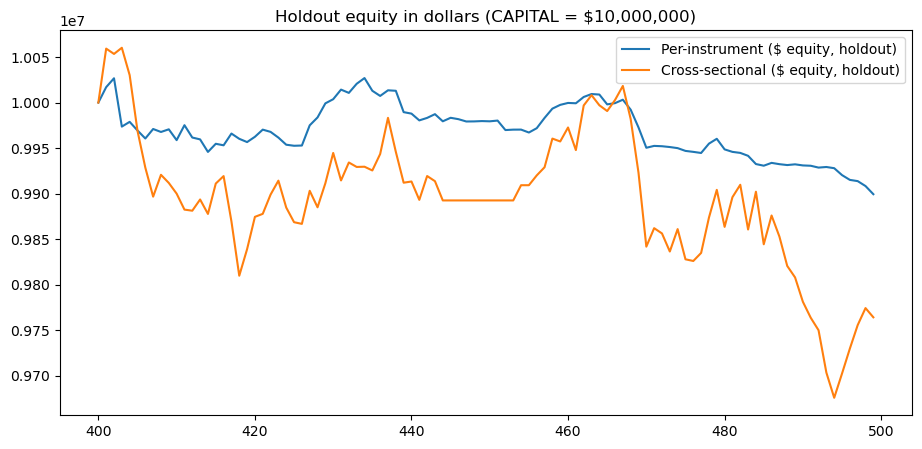


Most recent day's largest $ positions - per-instrument book:
RRES   -180948.0
EELT   -124223.0
ANSO    -99357.0
IHOZ     81919.0
HETT    -50844.0
CCNS    -22597.0
ALGO         0.0
HRND         0.0
GARI         0.0
RCRI         0.0
Name: 499, dtype: float64

Most recent day's largest $ positions - cross-sectional book:
EELT   -500000.0
RRES   -500000.0
FCSG    500000.0
AGVF    500000.0
ITPA    500000.0
IHOZ    500000.0
ANSO   -500000.0
AENO         0.0
RCRI         0.0
ACIX         0.0
Name: 499, dtype: float64

Net $ exposure (sum across instruments) - what the ALGO hedge overlay would need to offset:
per-instrument book: -396050.0
cross-sectional book: 500000.0


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
365,0.0,-69.302931,0.000000,51.767307,0.0,0.0,-25.123478,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-98.581687,58.188957,33.251381,-21.175641,0.0,0.0
366,0.0,-88.097592,0.000000,39.597595,0.0,0.0,-14.973884,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-108.646859,68.891307,0.215781,-17.387841,0.0,0.0
367,0.0,-54.111964,0.000000,49.193048,0.0,0.0,23.102284,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-114.482148,81.462379,-4.758798,-6.332765,0.0,0.0
368,0.0,-38.837544,0.000000,37.865817,0.0,0.0,36.280488,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-134.313561,77.027932,0.000000,-19.049333,0.0,0.0
369,0.0,-43.750987,9.588999,19.890624,0.0,0.0,40.624417,0.0,0.0,0.0,...,0.0,0.0,0.0,100.296211,-120.230323,82.590702,0.000000,-11.322033,0.0,0.0


In [195]:
CAPITAL = 10_000_000  # placeholder book size for this sleeve - update to the real allocation
N_INSTRUMENTS = df.shape[1]

# --- audit: prove the position cap actually held everywhere, don't just assume it ---
for name, w in [("ts OOS", ts_weight_oos), ("cs OOS", cs_weight_oos),
                ("ts holdout", ts_weight_holdout), ("cs holdout", cs_weight_holdout)]:
    max_abs = w.abs().max().max()
    assert max_abs <= MAX_POSITION_PCT + 1e-9, f"{name} breached MAX_POSITION_PCT: {max_abs:.4f}"
    print(f"{name}: max |weight| = {max_abs:.4f} (cap {MAX_POSITION_PCT}) - OK")

# --- audit: how often did the breadth floor actually sit out a leg? ---
cs_long_gross = cs_weight_oos.clip(lower=0).sum(axis=1)
cs_short_gross = cs_weight_oos.clip(upper=0).sum(axis=1)
print(f"\ncs OOS: long leg sat out on {(cs_long_gross == 0).sum()}/{len(cs_long_gross)} days, "
      f"short leg on {(cs_short_gross == 0).sum()}/{len(cs_short_gross)} days")

# --- walk-forward OOS, in dollars ---
ts_dollar_positions_oos = ts_weight_oos * CAPITAL
cs_dollar_positions_oos = cs_weight_oos * CAPITAL

ts_dollar_pnl_oos = (ts_dollar_positions_oos * returns_build.loc[ts_weight_oos.index]).sum(axis=1)
cs_dollar_pnl_oos = (cs_dollar_positions_oos * returns_build.loc[cs_weight_oos.index, cs_weight_oos.columns]).sum(axis=1)

print("\ndollar P&L matches weight-based return x CAPITAL:",
      np.allclose(ts_dollar_pnl_oos.fillna(0), (CAPITAL * ts_oos).fillna(0), atol=1e-6),
      np.allclose(cs_dollar_pnl_oos.fillna(0), (CAPITAL * cs_oos).fillna(0), atol=1e-6))

# --- holdout, in dollars ---
ts_dollar_positions_holdout = ts_weight_holdout * CAPITAL
cs_dollar_positions_holdout = cs_weight_holdout * CAPITAL

ts_dollar_equity = CAPITAL * (1 + ts_holdout.fillna(0)).cumprod()
cs_dollar_equity = CAPITAL * (1 + cs_holdout.fillna(0)).cumprod()

pd.DataFrame({
    "Per-instrument ($ equity, holdout)": ts_dollar_equity,
    "Cross-sectional ($ equity, holdout)": cs_dollar_equity,
}).plot(figsize=(11, 5), title=f"Holdout equity in dollars (CAPITAL = ${CAPITAL:,.0f})")
plt.show()

print("\nMost recent day's largest $ positions - per-instrument book:")
print(ts_dollar_positions_holdout.iloc[-1].reindex(ts_dollar_positions_holdout.iloc[-1].abs().sort_values(ascending=False).index).head(10).round(0))

print("\nMost recent day's largest $ positions - cross-sectional book:")
print(cs_dollar_positions_holdout.iloc[-1].reindex(cs_dollar_positions_holdout.iloc[-1].abs().sort_values(ascending=False).index).head(10).round(0))

print("\nNet $ exposure (sum across instruments) - what the ALGO hedge overlay would need to offset:")
print("per-instrument book:", round(ts_dollar_positions_holdout.iloc[-1].sum(), 0))
print("cross-sectional book:", round(cs_dollar_positions_holdout.iloc[-1].sum(), 0))

# --- conviction handoff, in dollars too (same capital-slice convention as the positions above) ---
ts_conviction_dollars = ts_conviction * (CAPITAL / N_INSTRUMENTS)
cs_conviction_dollars = cs_conviction * CAPITAL
momentum_conviction_dollars = ts_conviction_dollars.add(cs_conviction_dollars, fill_value=0.0)

momentum_conviction_dollars.tail()

### Handoff notes

- **Deliverable for the combiner**: `momentum_conviction` (return units) and `momentum_conviction_dollars` (dollar units, off a placeholder `CAPITAL` - swap in the real allocation) - out-of-sample, zeroed on instrument-days that fail the ADX+Hurst trend filter, ready to sit alongside Reji's and Cooky's contributions.
- **Stop-loss overlay**: per-position, `STOP_LOSS_PCT=8%` with a `STOP_LOSS_COOLDOWN=10`-day re-entry lockout, applied as a sequential (non-vectorized, lookahead-audited) pass on top of the walk-forward-selected weights. Before/after comparison is printed above - check it before assuming the stop is a free improvement; it isn't always one.
- **Position limits**: `MIN_NAMES_PER_LEG=3` (a leg sits out entirely below this breadth) and `MAX_POSITION_PCT=5%` (hard cap, clipped not redistributed) are enforced inside `ts_weights_from_signal`/`cs_weights_from_signal` themselves, not bolted on afterward - the walk-forward search and holdout only ever see positions that already satisfy them. Verified with asserts in the dollar-sizing section, not just assumed.
- **Dollar positions**: `ts_dollar_positions_oos`/`_holdout` and `cs_dollar_positions_oos`/`_holdout` give the actual per-instrument dollar exposure of each book (post-stop-loss). Net dollar exposure per day (summed across instruments) is what the ALGO hedge overlay would need to offset - printed above for the most recent holdout day as an example.
- **ALGO / market factor**: confirmed ~0.99 correlation with an equal-weight basket of the other 50 instruments. Cross-sectional momentum trades ALGO-residual returns and excludes ALGO from its universe. Per-instrument momentum is untouched (raw returns, keeps beta) - that beta is exactly what the portfolio-level ALGO hedge overlay should be netting out, so no need to double-hedge here. (Checked empirically: this book's beta to ALGO is already tiny, ~-0.03, so hedging it wouldn't have moved the Sharpe anyway - the negative Sharpe isn't a beta problem.)
- **Hurst screen**: added because the autocorrelation check found most instruments mean-revert, not trend, at momentum's horizons - ADX alone can't distinguish a real trend from a sharp reversal. `HURST_THRESHOLD=0.5` is fixed, not grid-searched, on purpose.
- **`neutralize_vs_algo`** is written generically (rolling beta of anything vs ALGO) - reusable as-is for the hedge overlay's rolling ALGO-offset calculation.
- **Walk-forward params per fold** are printed above (`fold_params`) - worth a glance for stability; if the winning horizon-set/threshold swings wildly fold to fold, that's a sign of overfitting the grid search rather than a real regime change.
- Full-sample exploratory section earlier in the notebook is for intuition only - trust the walk-forward OOS numbers and the holdout, not that first backtest.
- None of the thresholds here (including the position limits and the stop-loss) were tuned to hit a target Sharpe. If the honest number isn't where we'd like it, that's a finding about this instrument universe (worth a conversation with the team, especially Cooky/Warny given the mean-reversion angle), not something to fix by searching for parameters until the backtest looks better.